In [129]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa import arima_process
from statsmodels.tools.eval_measures import aic 
import matplotlib.pyplot as plt
import math

In [130]:
#Yule-walker equation
def yw(d,o):    #o=order of ar model
    avg=np.mean(d)
    n=len(d)
    d=d-avg       #mean centered
    #finding autocovariance function
    acvf=np.zeros(o+1)
    for i in range(0,o+1):
        if i==0:
            val=np.sum(d*d)/n
        else:
            val=np.sum(d[:-i]*d[i:])/n
        acvf[i]=val
    #finding errors, and coefficients
    alpha=np.zeros((o+1,o+1))    #coefficients 
    error=np.zeros(o+1)
    #initialization
    error[0]=acvf[0]
    alpha[1,1]=acvf[1]/error[0]
    error[1]=error[0]*(1-alpha[1,1]**2) 
    for k in range(2,o+1):
        f=k-1
        val=np.sum(alpha[f,1:k]*acvf[1:k][::-1])
        alpha[k,k]=(acvf[k]-val)/error[f]
        error[k]=error[f]*(1-alpha[k,k]**2) 
        #coefficients updates
        for c in range(1,k):
            alpha[k,c]=alpha[f,c]-alpha[k,k]*alpha[f,k-c]
    sqerrorvar=acvf[0]-np.dot(alpha[-1,1:],acvf[1:]) ##variance of error of noise
    return alpha[-1,1:],sqerrorvar

In [131]:
#Hannan-Rissanen Algorithm
def hanris(d,p,q): #p and q are order of AR and ma respectively
    #find the order 'm' greater than p+q using AIC
    n=len(d)
    min_aic=float('inf')
    best_coeff=None
    best_order=None
    lower_bound=p+q+1
    upper_bound=int(min((n*0.35,np.log(n)**2)))
    for i in range(lower_bound,upper_bound+1):
        res=yw(d,i)#using yule wlaker equation to find coefficients
        # print(f"DEBUG loop {i}: yw returned {res}")
        coeff,sqerrorvar=res
        standarized_aic=np.log(sqerrorvar)+((2*i)/n)
        if standarized_aic<min_aic:
            min_aic=standarized_aic
            best_coeff=coeff 
            best_order=i
    davg=d-np.mean(d)
    #Residual exraction from high order AR model
    residual=np.zeros(n)
    for j in range(best_order,n):
        residual[j]=davg[j]-np.dot(best_coeff,d[j-best_order:j][::-1])
        
    #Oridinary Least Squares 
    ## Mathematically,here AR should start at t=m+1 and ma looks back q step to zt. then t=m+1+q . 
    ## so for Y=B.Z+e here Y starts at m+1+q i.e m+q in python ,where m is best order
    start= best_order+q
    num_obs=n-start
    y=davg[start:n] #target vector
    # regression matrix 
    z=np.zeros((num_obs,p+q))
    for i,t in enumerate(range(start,n)):
        ar_term=davg[t-1:t-p-1:-1] if p>0 else []
        ma_term=residual[t-1:t-q-1:-1] if q>0 else []
        z[i]=np.concatenate([ar_term,ma_term])
    coeff,*_=np.linalg.lstsq(z,y,rcond=None)
    ar_coeff=coeff[:p] if p>0 else np.array([])
    ma_coeff=coeff[p:p+q] if q>0 else np.array([])
    return min_aic,best_order,ar_coeff,ma_coeff  

In [150]:
#Generating Samples of ARMA model
def generate_sample(oar,oma,nsample): #oar and oma being original ar parameters and ma parameters ,must be passed in list format
    np.random.seed(67890) 
    arpar=np.array(oar) # coefficients of Ar model
    mapar=np.array(oma)  # coefficients of Ma model
    ar_par=np.r_[1,-arpar]   #arima_process takes coefficient in form of Yt-0.75X(t-1)+0.26X(t-2)=error
    ma_par=np.r_[1,mapar]
    sy=arima_process.arma_generate_sample(ar_par,ma_par,nsample)
    return sy

IndentationError: unexpected indent (1071567141.py, line 3)

In [139]:
min_aic,best_order,ar_coeff,ma_coeff=hanris(sy,3,1)
print(min_aic)
print(best_order)
print(ar_coeff)
print(ma_coeff)

0.03833352738099696
5
[ 0.30923562 -0.54526792  0.15529637]
[0.46686878]


In [153]:
#plot of AR coefficients and MA coefficients w.r.to sample sizes
def plot(oar,oma,max_sample):
    arpar=[]
    mapar=[]
    p = len(oar)
    q = len(oma)
    sample_sizes = list(range(100, max_sample, 100))
    for n,i in enumerate(sample_sizes):
        sy=generate_sample(oar,oma,i) #oar and oma being original ar parameters and ma parameters
        *_,ar_coeff,ma_coeff=hanris(sy,p,q)
        arpar.append(ar_coeff)
        mapar.append(ma_coeff)
        # Convert lists of arrays into 2D numpy arrays for easy column slicing
    arpar_matrix = np.array(arpar)
    mapar_matrix = np.array(mapar)
    
    
    total_plots = p + q
    cols = 2
    rows = math.ceil(total_plots / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    fig.suptitle(f'Hannan-Rissanen Convergence: ARMA({p},{q})', fontsize=16)
    
    # Flatten axes array for easy 1D iteration
    if total_plots > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
        
    plot_idx = 0
    
    # Plot all AR coefficients and MA coefficients
    for j in range(p):
        ax = axes[plot_idx]
        # arpar_matrix[:, j] extracts the j-th coefficient for all sample sizes
        ax.plot(sample_sizes, arpar_matrix[:, j], marker='o', color='blue', label='Estimated')
        ax.axhline(y=oar[j], color='black', linestyle='--', linewidth=2, label=f'True: {oar[j]}')
        ax.set_title(rf'AR({j+1}) Coefficient ($\phi_{j+1}$)')
        ax.set_xlabel('Sample Size (n)')
        ax.set_ylabel('Coefficient Value')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plot_idx += 1
        
    for j in range(q):
        ax = axes[plot_idx]
        # mapar_matrix[:, j] extracts the j-th coefficient for all sample sizes
        ax.plot(sample_sizes, mapar_matrix[:, j], marker='o', color='red', label='Estimated')
        ax.axhline(y=oma[j], color='black', linestyle='--', linewidth=2, label=f'True: {oma[j]}')
        ax.set_title(rf'MA({j+1}) Coefficient ($\theta_{j+1}$)')
        ax.set_xlabel('Sample Size (n)')
        ax.set_ylabel('Coefficient Value')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plot_idx += 1
    for k in range(plot_idx, len(axes)):
        fig.delaxes(axes[k])
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.savefig("3.png")
    plt.show()
        

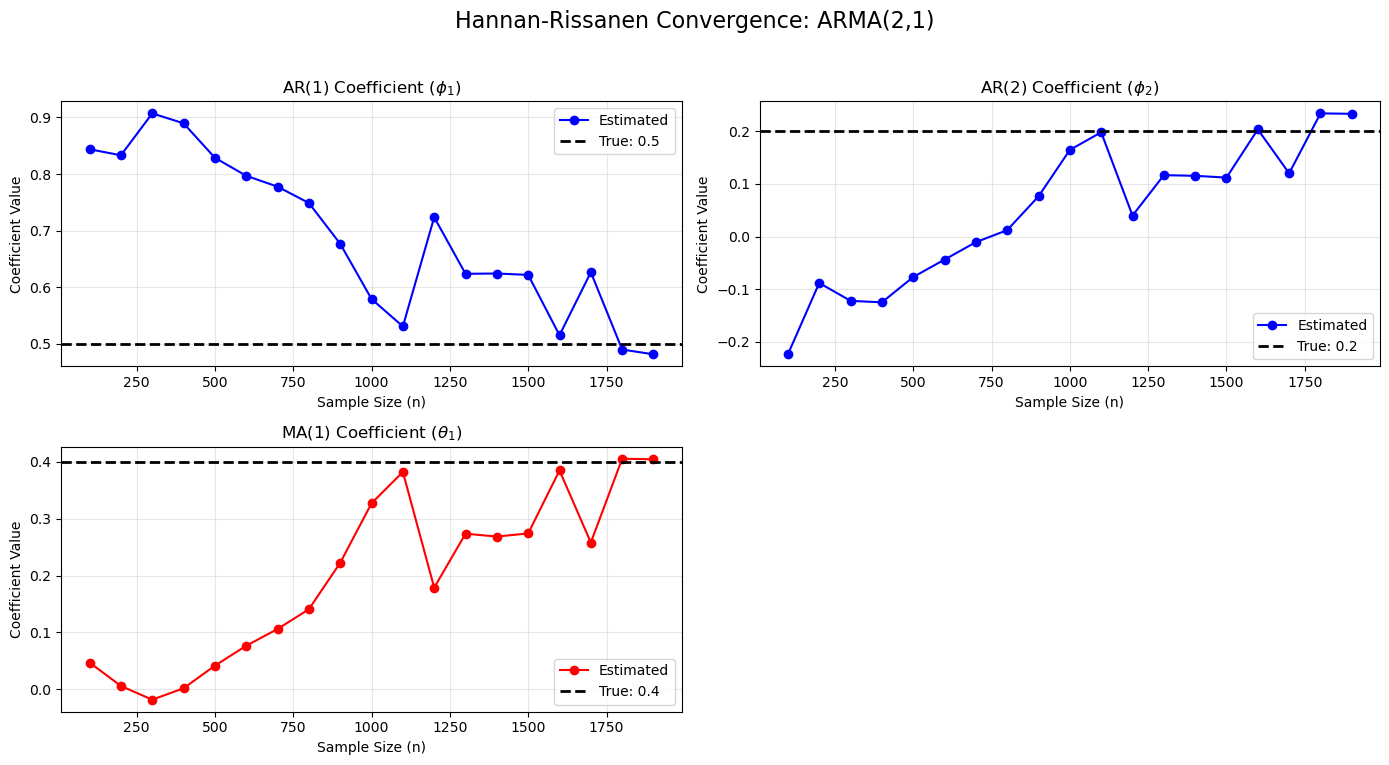

In [152]:
plot([0.5,0.2],[0.4],2000)

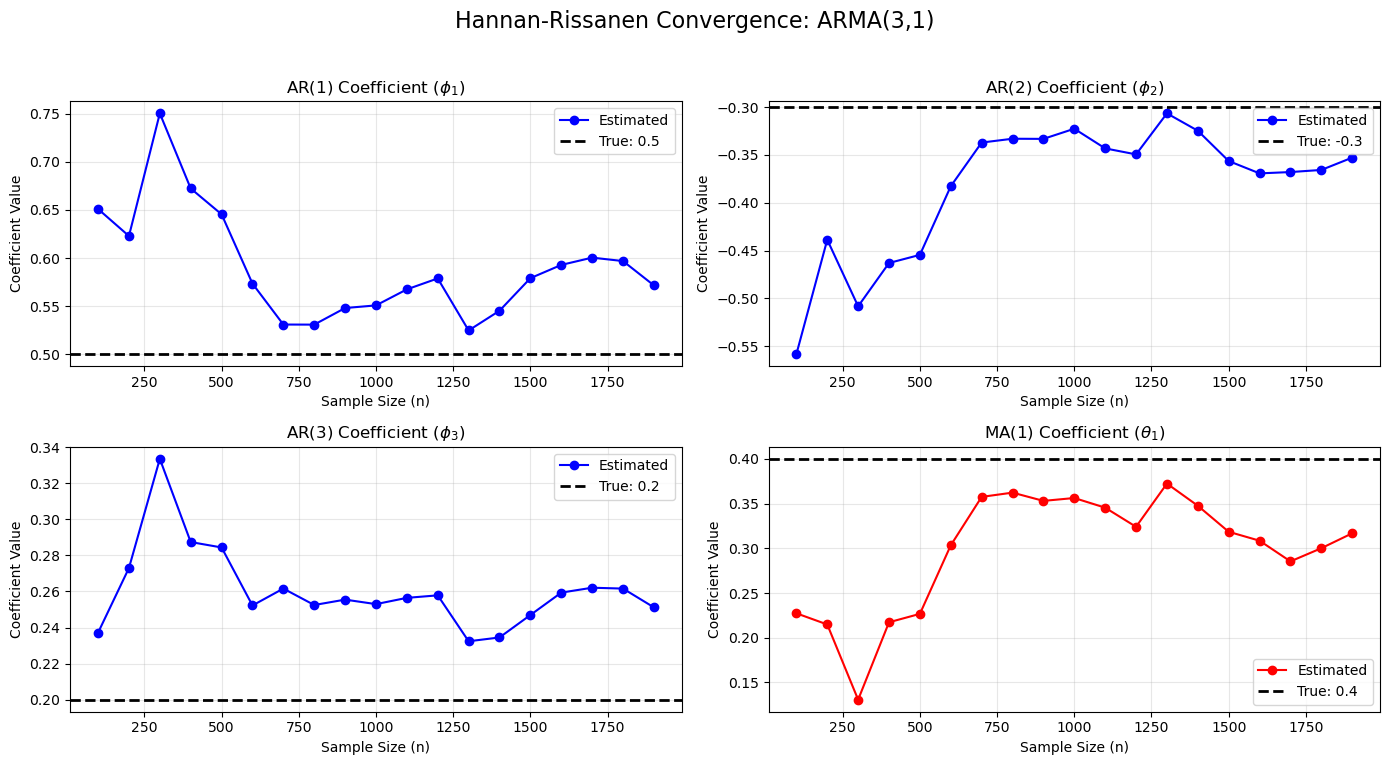

In [154]:
plot([0.5,-0.3,0.2],[0.4],2000)